# Spendable — Stage 2: Recurring Payment & Financial Commitment Detection

## 1. Overview & Core Objectives

This notebook explores point-in-time detection of recurring financial commitments (rent, utilities, subscriptions, salaries, loan EMIs, education fees, family support) using **only** observable transaction histories up to snapshot cutoff $T$.

### Key Constraints & Invariants
- **No Ground Truth Leakage**: Hidden planted rule labels and persona data are strictly isolated and used ONLY during offline performance evaluation.
- **Strict Point-in-Time Cutoff**: Detector evaluates transactions where $t \le T$. Future transactions ($t > T$) are excluded.
- **User Split Isolation**: Dataset remains split into 350 `TRAIN`, 75 `VALIDATION`, and 75 `TEST` user accounts.

In [1]:
import sys
from pathlib import Path
import json
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Add backend to sys.path
backend_path = Path('../backend').resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.recurring.detector import RecurringDetector
from app.recurring.evaluator import RecurringEvaluator
from app.recurring.schema import DetectionConfig, DetectionStatus

sns.set_theme(style='whitegrid')
print('Recurring detection module imported successfully!')

Recurring detection module imported successfully!


## 2. Load Observable Transactions & Hidden Ground Truth

Load 98,884 historical transactions across 500 synthetic user accounts.

In [2]:
data_dir = Path('../data')
with open(data_dir / 'transactions.json', 'r', encoding='utf-8') as f:
    transactions = json.load(f)
with open(data_dir / 'ground_truth.json', 'r', encoding='utf-8') as f:
    gt_data = json.load(f)

snapshot_time = datetime(2026, 10, 1)
print(f'Loaded {len(transactions):,} transactions across {len(gt_data["users"])} users.')
print(f'Snapshot Cutoff Date T: {snapshot_time.strftime("%Y-%m-%d")}')

Loaded 98,884 transactions across 500 users.
Snapshot Cutoff Date T: 2026-10-01


## 3. Sample User Commitment Detection (`ACC-0001`)

Demonstrate point-in-time recurring commitment detection for single user `ACC-0001`.

In [3]:
config = DetectionConfig(strong_threshold=0.70, moderate_threshold=0.45)
detector = RecurringDetector(config)

acc1_txs = [t for t in transactions if t['account_id'] == 'ACC-0001']
acc1_commitments = detector.detect(acc1_txs, snapshot_time)

comm_data = []
for c in acc1_commitments:
    comm_data.append({
        'Counterparty': c.counterparty_name or 'N/A',
        'Category': c.category,
        'Expected Amount': c.expected_amount,
        'Interval': c.recurrence_interval.value,
        'Median Days': c.median_interval_days,
        'Occurrences': c.occurrence_count,
        'Next Expected': c.next_expected_date,
        'Confidence': c.confidence_score,
        'Status': c.detection_status.value,
    })

df_acc1 = pd.DataFrame(comm_data)
print('Detected Commitments for ACC-0001:')
display(df_acc1)

Detected Commitments for ACC-0001:


,Counterparty,Category,Expected Amount,Interval,Median Days,Occurrences,Next Expected,Confidence,Status
0,City Bank EMI,DEBT_PAYMENT,8679.00,MONTHLY,30.96,9,2026-10-08,1.00,STRONG
1,Dotlines Fiber Internet,UTILITIES,2916.00,MONTHLY,30.99,9,2026-10-11,1.00,STRONG
2,Google One & Cloud Services,SOFTWARE,867.68,MONTHLY,30.96,9,2026-10-19,1.00,STRONG
3,Fitness Plus Gym Membership,FITNESS,3500.00,MONTHLY,30.98,9,2026-10-23,1.00,STRONG
4,Enterprise Payroll Services,INCOME,61508.20,MONTHLY,30.98,9,2026-10-04,0.99,STRONG
5,Luxury Apartments Co,HOUSING,15785.90,MONTHLY,30.96,9,2026-10-03,0.99,STRONG
6,Spotify Music Premium,ENTERTAINMENT,399.00,MONTHLY,30.98,9,2026-10-15,0.93,STRONG
7,Netflix Streaming Subscription,ENTERTAINMENT,1499.00,MONTHLY,30.99,9,2026-10-13,0.93,STRONG
8,Nando's BD,DINING,685.42,WEEKLY,5.09,34,2026-10-05,0.59,MODERATE
9,Chillox Burgers,DINING,900.90,WEEKLY,8.90,30,2026-10-08,0.56,MODERATE


## 4. Population Detection & Visualizing Interval Distributions

Run recurring detection across all accounts at snapshot $T$ and inspect confidence score and periodicity distributions.

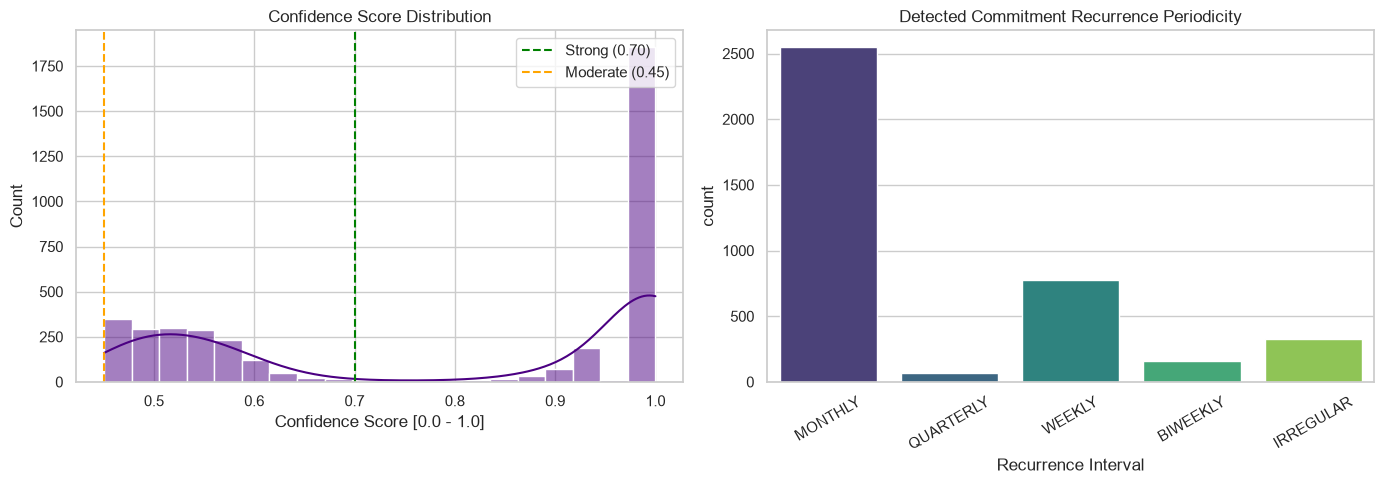

In [4]:
all_commitments = detector.detect(transactions, snapshot_time)
df_all = pd.DataFrame([c.model_dump() for c in all_commitments])
# Clean interval label for display
df_all['recurrence_interval'] = df_all['recurrence_interval'].astype(str).apply(lambda x: x.split('.')[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_all['confidence_score'], bins=20, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Confidence Score [0.0 - 1.0]')
axes[0].axvline(0.70, color='green', linestyle='--', label='Strong (0.70)')
axes[0].axvline(0.45, color='orange', linestyle='--', label='Moderate (0.45)')
axes[0].legend()

sns.countplot(
    data=df_all,
    x='recurrence_interval',
    hue='recurrence_interval',
    ax=axes[1],
    palette='viridis',
    legend=False
)
axes[1].set_title('Detected Commitment Recurrence Periodicity')
axes[1].set_xlabel('Recurrence Interval')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Offline Ground-Truth Evaluation across Dataset Splits

Evaluate detector metrics against hidden planted recurring rules on `TRAIN`, `VALIDATION`, and `TEST` splits.

In [5]:
evaluator = RecurringEvaluator(gt_data)
report = evaluator.evaluate_all_splits(detector, transactions, snapshot_time)

metrics_list = []
for m in [report.train_metrics, report.validation_metrics, report.test_metrics]:
    metrics_list.append({
        'Split': m.split_name,
        'Users': m.total_users,
        'GT Rules': m.ground_truth_rules_count,
        'Detected': m.detected_commitments_count,
        'TP': m.true_positives,
        'FP': m.false_positives,
        'FN': m.false_negatives,
        'Precision': m.precision,
        'Recall': m.recall,
        'F1 Score': m.f1_score,
    })

df_report = pd.DataFrame(metrics_list)
print('=== RECURRING DETECTION EVALUATION SUMMARY REPORT ===')
display(df_report)

=== RECURRING DETECTION EVALUATION SUMMARY REPORT ===


,Split,Users,GT Rules,Detected,TP,FP,FN,Precision,Recall,F1 Score
0,TRAIN,350,1485,2625,1476,1149,9,0.56,0.99,0.72
1,VALIDATION,75,360,611,360,251,0,0.59,1.00,0.74
2,TEST,75,363,638,362,276,1,0.57,1.00,0.72


## 6. False Positive & False Negative Error Analysis

Analyze categories and patterns responsible for false positive and false negative detections.

In [6]:
train_users = {uid for uid, sname in evaluator.user_splits.items() if sname == 'TRAIN'}
train_txs = [t for t in transactions if t['account_id'] in train_users]
train_dets = detector.detect(train_txs, snapshot_time)

gt_rules_train = []
for uid in train_users:
    gt_rules_train.extend(gt_data['users'][uid].get('planted_rules', []))

matched_gt_ids = set()
fp_records = []

for det in train_dets:
    matched = False
    for r in gt_rules_train:
        if r['account_id'] == det.user_id:
            rel_diff = abs(det.expected_amount - float(r['base_amount'])) / max(float(r['base_amount']), 1.0)
            if rel_diff <= 0.35:
                cp1 = (det.counterparty_name or '').lower()
                cp2 = str(r.get('counterparty_name') or '').lower()
                cat1 = (det.category or '').lower()
                cat2 = str(r.get('category') or '').lower()
                act2 = str(r.get('activity_type') or '').lower()
                if (cp1 and cp2 and (cp1 in cp2 or cp2 in cp1)) or (cat1 == cat2 or cat1 == act2):
                    matched = True
                    matched_gt_ids.add(r['rule_id'])
                    break
    if not matched:
        fp_records.append(det.model_dump())

df_fp = pd.DataFrame(fp_records)
print(f'Total False Positives on TRAIN: {len(df_fp)}')
if not df_fp.empty:
    print('\nFalse Positive Top Categories:')
    print(df_fp['category'].value_counts().head(10))

Total False Positives on TRAIN: 1148

False Positive Top Categories:
category
DINING                    217
FOOD_AND_DINING           175
DISCRETIONARY_SHOPPING    173
GENERAL_PURCHASE          162
ENTERTAINMENT              91
FOOD_AND_GROCERIES         88
FREELANCE_INCOME           88
TRANSPORT                  87
MEDICAL_OR_EMERGENCY       65
HOUSING                     1
Name: count, dtype: int64
